In [1]:
import pandas as pd
from pathlib import Path
import numpy as np 
import matplotlib.pyplot as plt

import sys
sys.path.insert(0, "..")   

In [2]:
%reload_ext autoreload
%autoreload 2

In [34]:
df = pd.read_csv("../output/data/502_BraTS2017_training_metrics.csv")
df.head()

,epoch,epoch_time_sec,ts_first,ts_last,lr,train_loss,val_loss,Necrotic_Dice,Edema_Dice,Enhancing_Dice,EMA_DICE,src_file
0,0,499.14,2025-10-09 09:18:32.487246,2025-10-09 09:26:51.700264,0.01000,-0.4202,-0.6731,0.8372,0.7485,0.7854,0.7904,training_log_2025_10_9_09_16_50.txt
1,1,367.48,2025-10-09 09:26:54.579283,2025-10-09 09:33:02.111999,0.00999,-0.7489,-0.7546,0.8889,0.8004,0.8066,0.7945,training_log_2025_10_9_09_16_50.txt
2,2,360.84,2025-10-09 09:33:08.170560,2025-10-09 09:39:09.001812,0.00998,-0.7978,-0.7694,0.8955,0.8002,0.8042,0.7984,training_log_2025_10_9_09_16_50.txt
3,3,363.43,2025-10-09 09:39:12.610572,2025-10-09 09:45:16.123588,0.00997,-0.8237,-0.7835,0.8981,0.8134,0.8097,0.8026,training_log_2025_10_9_09_16_50.txt
4,4,384.53,2025-10-09 09:45:20.761085,2025-10-09 09:51:45.324018,0.00996,-0.8361,-0.7918,0.9040,0.8166,0.8016,0.8064,training_log_2025_10_9_09_16_50.txt


In [35]:
df.drop(columns=["ts_first", "ts_last", "src_file"], inplace=True)

In [36]:
df.dtypes

epoch               int64
epoch_time_sec    float64
lr                float64
train_loss        float64
val_loss          float64
Necrotic_Dice     float64
Edema_Dice        float64
Enhancing_Dice    float64
EMA_DICE          float64
dtype: object

In [37]:
df

,epoch,epoch_time_sec,lr,train_loss,val_loss,Necrotic_Dice,Edema_Dice,Enhancing_Dice,EMA_DICE
0,0,499.14,0.01000,-0.4202,-0.6731,0.8372,0.7485,0.7854,0.7904
1,1,367.48,0.00999,-0.7489,-0.7546,0.8889,0.8004,0.8066,0.7945
2,2,360.84,0.00998,-0.7978,-0.7694,0.8955,0.8002,0.8042,0.7984
3,3,363.43,0.00997,-0.8237,-0.7835,0.8981,0.8134,0.8097,0.8026
4,4,384.53,0.00996,-0.8361,-0.7918,0.9040,0.8166,0.8016,0.8064
...,...,...,...,...,...,...,...,...,...
995,995,369.23,0.00008,-0.9489,-0.8129,0.9173,0.8609,0.8070,NaN
996,996,374.11,0.00007,-0.9483,-0.8118,0.9223,0.8581,0.8035,NaN
997,997,376.27,0.00005,-0.9488,-0.8225,0.9224,0.8635,0.8073,NaN
998,998,364.63,0.00004,-0.9490,-0.8144,0.9201,0.8661,0.8198,NaN


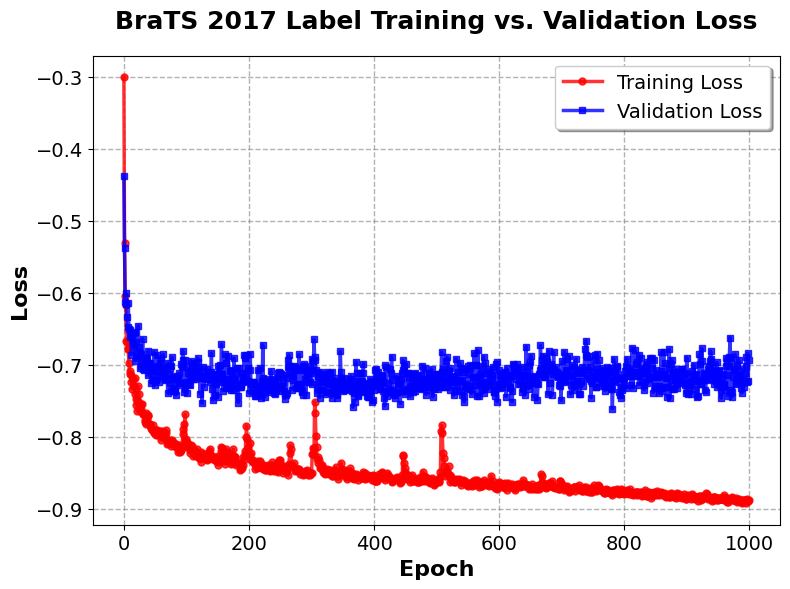

In [30]:
# Create figure with custom styling
fig, ax = plt.subplots(figsize=(8, 6))

# Combined plot with both training and validation loss
ax.plot(df["epoch"], df["train_loss"], 'r-', linewidth=2.5, marker='o', 
        markersize=5, label='Training Loss', alpha=0.8)
ax.plot(df["epoch"], df["val_loss"], 'b-', linewidth=2.5, marker='s', 
        markersize=5, label='Validation Loss', alpha=0.8)

# Styling
ax.set_title("BraTS 2017 Label Training vs. Validation Loss", fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel("Epoch", fontsize=16, fontweight='bold')
ax.set_ylabel("Loss", fontsize=16, fontweight='bold')
ax.legend(fontsize=14, loc='upper right', frameon=True, shadow=True)
ax.tick_params(axis='both', which='major', labelsize=14)

# White background and more visible grid
ax.set_facecolor('white')
fig.patch.set_facecolor('white')
ax.grid(True, alpha=0.6, linestyle='--', linewidth=1, color='gray')
ax.set_axisbelow(True)  # Put grid behind the plot lines

plt.tight_layout()
fn = Path("../output/figures/nnunet_brats2017_501_loss_fold0_plot.tiff")
plt.savefig(fn, dpi=300)
plt.show()
plt.close()

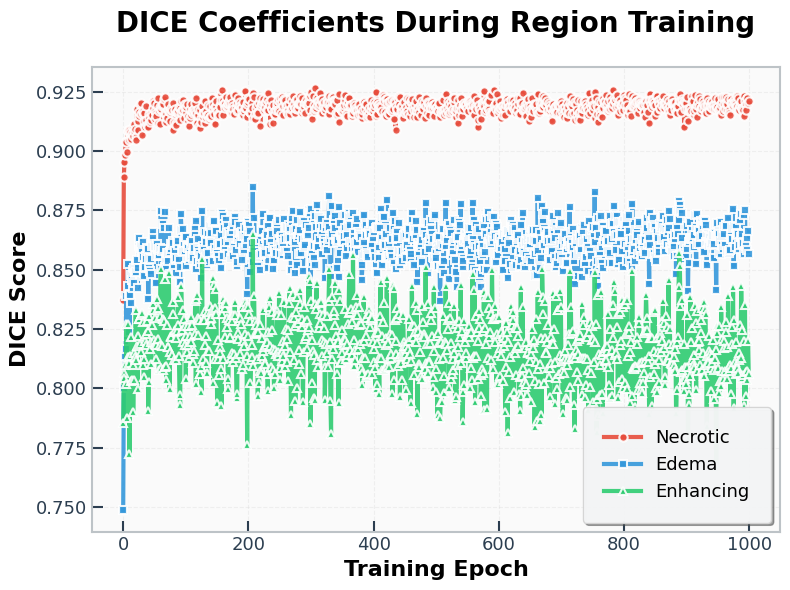

In [38]:

# Create figure with custom styling
fig, ax = plt.subplots(figsize=(8, 6))

# Define colors and markers
colors = ['#e74c3c', '#3498db', '#2ecc71']  # Red, Blue, Green
markers = ['o', 's', '^']
labels = ['Necrotic', 'Edema', 'Enhancing']

# Plot each DICE metric
for i, (col, marker, label) in enumerate(zip(['Necrotic_Dice', 'Edema_Dice', 'Enhancing_Dice'], markers, labels)):
    ax.plot(df["epoch"], df[col], color=colors[i], linewidth=3, marker=marker, 
            markersize=6, label=label, alpha=0.9, 
            markeredgecolor='white', markeredgewidth=1.5)

# Enhanced styling
ax.set_title("DICE Coefficients During Region Training", fontsize=20, fontweight='bold', pad=25)
ax.set_xlabel("Training Epoch", fontsize=16, fontweight='bold')
ax.set_ylabel("DICE Score", fontsize=16, fontweight='bold')

# Professional legend
legend = ax.legend(fontsize=13, loc='lower right', frameon=True, shadow=True, 
                   fancybox=True, borderpad=1.2, columnspacing=1)
legend.get_frame().set_facecolor('#f8f9fa')
legend.get_frame().set_alpha(0.95)
legend.get_frame().set_edgecolor('lightgray')

# Enhanced tick styling
ax.tick_params(axis='both', which='major', labelsize=13, direction='in', 
               length=8, width=1.5, colors='#2c3e50')
ax.tick_params(axis='both', which='minor', length=4, width=1, colors='#2c3e50')

# Grid and background
ax.set_facecolor('#fafafa')
fig.patch.set_facecolor('white')
ax.grid(True, alpha=0.5, linestyle='-', linewidth=0.5, color='white')
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.8, color='lightgray')
ax.set_axisbelow(True)

# Set axis limits if needed
# ax.set_ylim(0, 1)  # For DICE scores typically between 0 and 1

# Add subtle border
for spine in ax.spines.values():
    spine.set_edgecolor('#bdc3c7')
    spine.set_linewidth(1.5)

plt.tight_layout()

# Save with high quality
fn = Path("../output/figures/nnunet_brats2017_502_dice_fold0_plot.tiff")
plt.savefig(fn, dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')

plt.show()

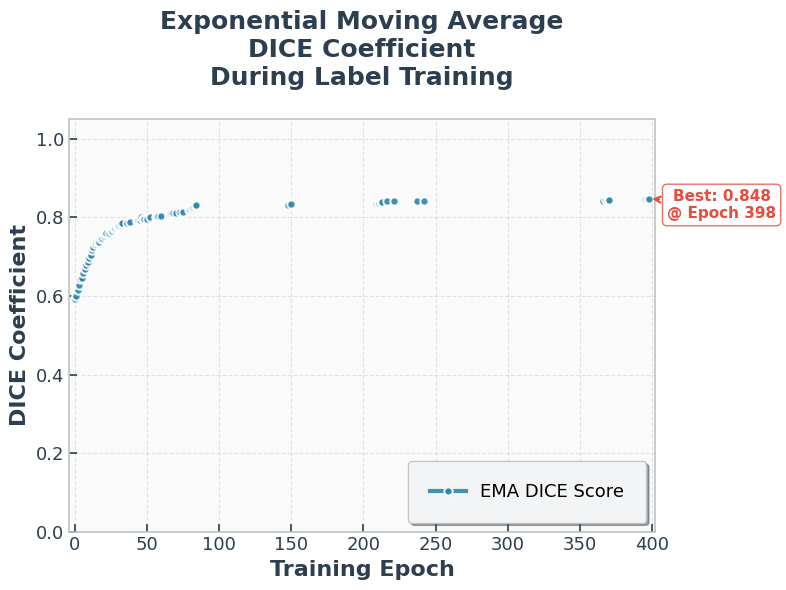

In [32]:
# Create figure with enhanced styling
fig, ax = plt.subplots(figsize=(8, 6))

# Plot EMA DICE with professional styling
ax.plot(df["epoch"], df["EMA_DICE"], color='#2E86AB', linewidth=3, marker='o', 
        markersize=6, label='EMA DICE Score', alpha=0.9, 
        markeredgecolor='white', markeredgewidth=1.5, markerfacecolor='#2E86AB')

# Enhanced styling
ax.set_title("Exponential Moving Average\nDICE Coefficient\nDuring Label Training", 
             fontsize=18, fontweight='bold', pad=25, color='#2c3e50')
ax.set_xlabel("Training Epoch", fontsize=16, fontweight='bold', color='#2c3e50')
ax.set_ylabel("DICE Coefficient", fontsize=16, fontweight='bold', color='#2c3e50')

# Professional legend
legend = ax.legend(fontsize=13, loc='lower right', frameon=True, shadow=True, 
                   fancybox=True, borderpad=1.2)
legend.get_frame().set_facecolor('#f8f9fa')
legend.get_frame().set_alpha(0.95)
legend.get_frame().set_edgecolor('#bdc3c7')

# Enhanced tick styling
ax.tick_params(axis='both', which='major', labelsize=13, direction='in', 
               length=6, width=1.2, colors='#2c3e50')

# Grid and background improvements
ax.set_facecolor('#fafafa')
fig.patch.set_facecolor('white')
ax.grid(True, alpha=0.4, linestyle='--', linewidth=0.8, color='#bdc3c7')
ax.set_axisbelow(True)

# Add subtle border styling
for spine in ax.spines.values():
    spine.set_edgecolor('#bdc3c7')
    spine.set_linewidth(1.2)

# Set appropriate y-axis limits for DICE scores
ax.set_ylim(0, 1.05)

# Add margins for better visualization
ax.margins(x=0.01)

# Add annotation for best score (optional)
best_epoch = df.loc[df["EMA_DICE"].idxmax(), "epoch"]
best_score = df["EMA_DICE"].max()
ax.annotate(f'Best: {best_score:.3f}\n@ Epoch {best_epoch}', 
            xy=(best_epoch, best_score), xytext=(best_epoch + 50, best_score - 0.05),
            arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=1.5),
            fontsize=11, ha='center', color='#e74c3c', fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.3", facecolor='white', edgecolor='#e74c3c', alpha=0.8))

plt.tight_layout()

# Save with descriptive filename
fn = Path("../output/figures/nnunet_brats2017_501_ema_dice_fold0_plot.tiff")
plt.savefig(fn, dpi=300, bbox_inches='tight', facecolor='white')

plt.show()